## **AutoML com H2o**

In [1]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd

In [2]:
h2o.init(
    nthreads=1,         # Usa absolutamente TODOS os núcleos do seu processador (rápido!)
    max_mem_size="8G",  # Reserva exatamente 8 Gigabytes de RAM EXCLUSIVOS para o Java
    port=54321          # (Opcional) Define a porta de comunicação
)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-1, mixed mode, sharing)
  Starting server from /home/joao-inac-io/AutoML-com--Python/.venv/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpfoz7u9p8
  JVM stdout: /tmp/tmpfoz7u9p8/h2o_joao_inac_io_started_from_python.out
  JVM stderr: /tmp/tmpfoz7u9p8/h2o_joao_inac_io_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,America/Fortaleza
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months
H2O_cluster_name:,H2O_from_python_joao_inac_io_f2lfr9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,1
H2O_cluster_status:,"locked, healthy"


In [3]:
# df = pd.read_csv("../data/Churn_treino.csv", sep=";")
# df = h2o.H2OFrame(df)
# df
df = h2o.import_file("../data/Churn_treino.csv", sep=";")
df

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
619,France,Female,42,2,0,1,1,1,1.01349e+07,1
608,Spain,Female,41,1,8.38079e+06,1,0,1,1.12543e+07,0
502,France,Female,42,8,1.59661e+06,3,1,0,1.13932e+07,1
699,France,Female,39,1,0,2,0,0,9.38266e+06,0
850,Spain,Female,43,2,1.25511e+07,1,1,1,790841,0
645,Spain,Male,44,8,1.13756e+07,2,1,0,1.49757e+07,1
822,France,Male,50,7,0,2,1,1,100628,0
376,Germany,Female,29,4,1.15047e+07,4,1,0,1.19347e+07,1
501,France,Male,44,4,1.42051e+07,2,0,1,749405,0
684,France,Male,27,2,1.34604e+07,1,1,1,7.17257e+06,0


In [4]:
treino, teste = df.split_frame(ratios=[0.7])

In [5]:
treino["Exited"] = treino["Exited"].asfactor()
teste["Exited"] = teste["Exited"].asfactor()

In [6]:
modelo = H2OAutoML(max_runtime_secs=60)
modelo.train(y="Exited", training_frame=treino)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),7/8
# GBM base models (used / total),4/4
# XGBoost base models (used / total),2/2
# DRF base models (used / total),0/1
# GLM base models (used / total),1/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
DRF_1_AutoML_1_20260512_165243,0.990502,0.143158,0.97461,0.0375918,0.176868,0.0312823,283,0.004141,DRF
GBM_4_AutoML_1_20260512_165243,0.940084,0.375755,0.837167,0.149546,0.336955,0.113539,282,0.016894,GBM
XGBoost_1_AutoML_1_20260512_165243,0.929555,0.263903,0.826859,0.158703,0.280001,0.0784005,1318,0.01419,XGBoost
StackedEnsemble_BestOfFamily_2_AutoML_1_20260512_165243,0.923653,0.281687,0.796436,0.16071,0.291819,0.0851584,1607,0.037151,StackedEnsemble
StackedEnsemble_AllModels_1_AutoML_1_20260512_165243,0.921022,0.294318,0.796334,0.171824,0.296267,0.0877743,1546,0.044877,StackedEnsemble
StackedEnsemble_BestOfFamily_1_AutoML_1_20260512_165243,0.919586,0.285604,0.788241,0.163901,0.294228,0.0865699,1635,0.045671,StackedEnsemble
GBM_1_AutoML_1_20260512_165243,0.918609,0.289502,0.784327,0.165314,0.296161,0.0877113,2360,0.029576,GBM
XGBoost_2_AutoML_1_20260512_165243,0.917947,0.29782,0.802287,0.174624,0.293857,0.0863521,345,0.00829,XGBoost
GBM_3_AutoML_1_20260512_165243,0.916855,0.379367,0.796425,0.184752,0.338708,0.114723,320,0.011735,GBM
GBM_2_AutoML_1_20260512_165243,0.900799,0.376603,0.771181,0.198517,0.337203,0.113706,307,0.021426,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_AllModels_1_AutoML_1_20260512_165243

,0,1,Error,Rate
0,4988.0,529.0,0.0959,(529.0/5517.0)
1,360.0,1093.0,0.2478,(360.0/1453.0)
Total,5348.0,1622.0,0.1275,(889.0/6970.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

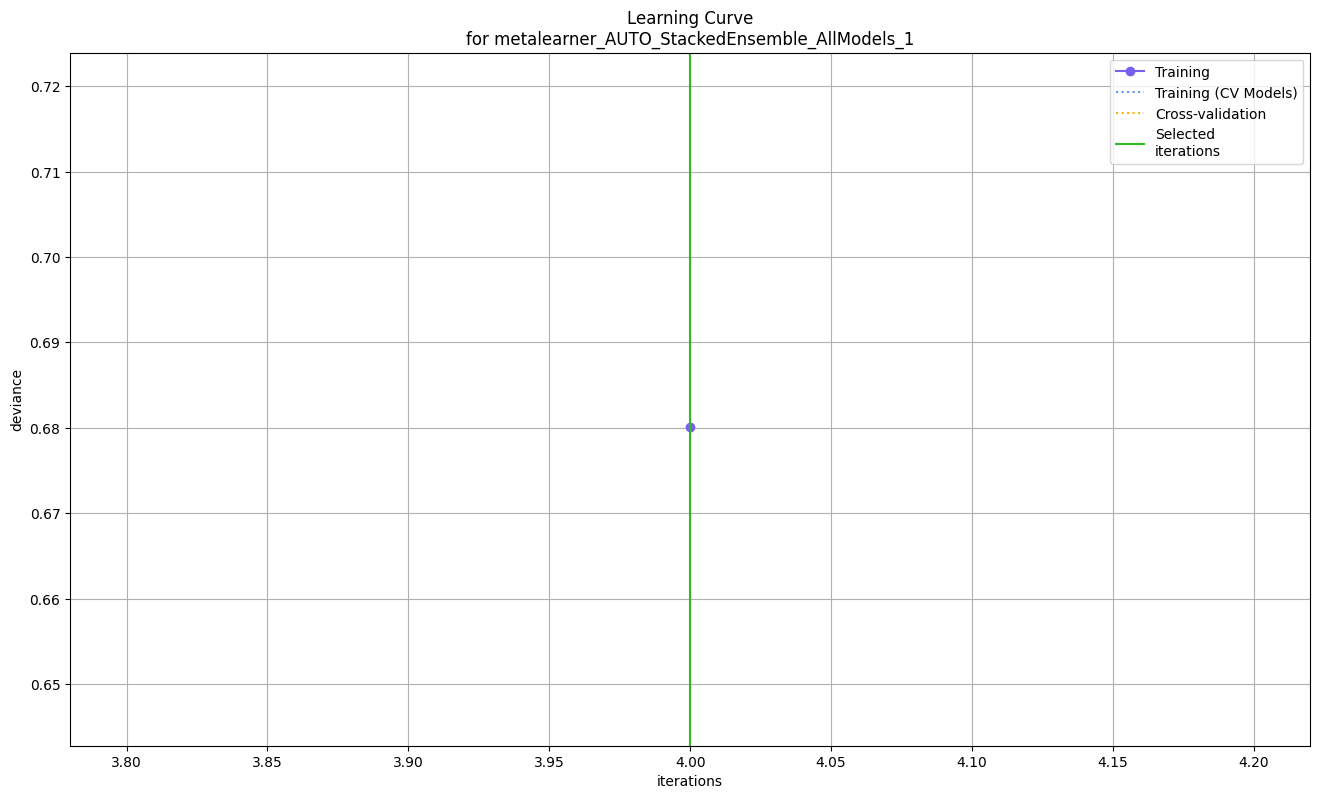

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

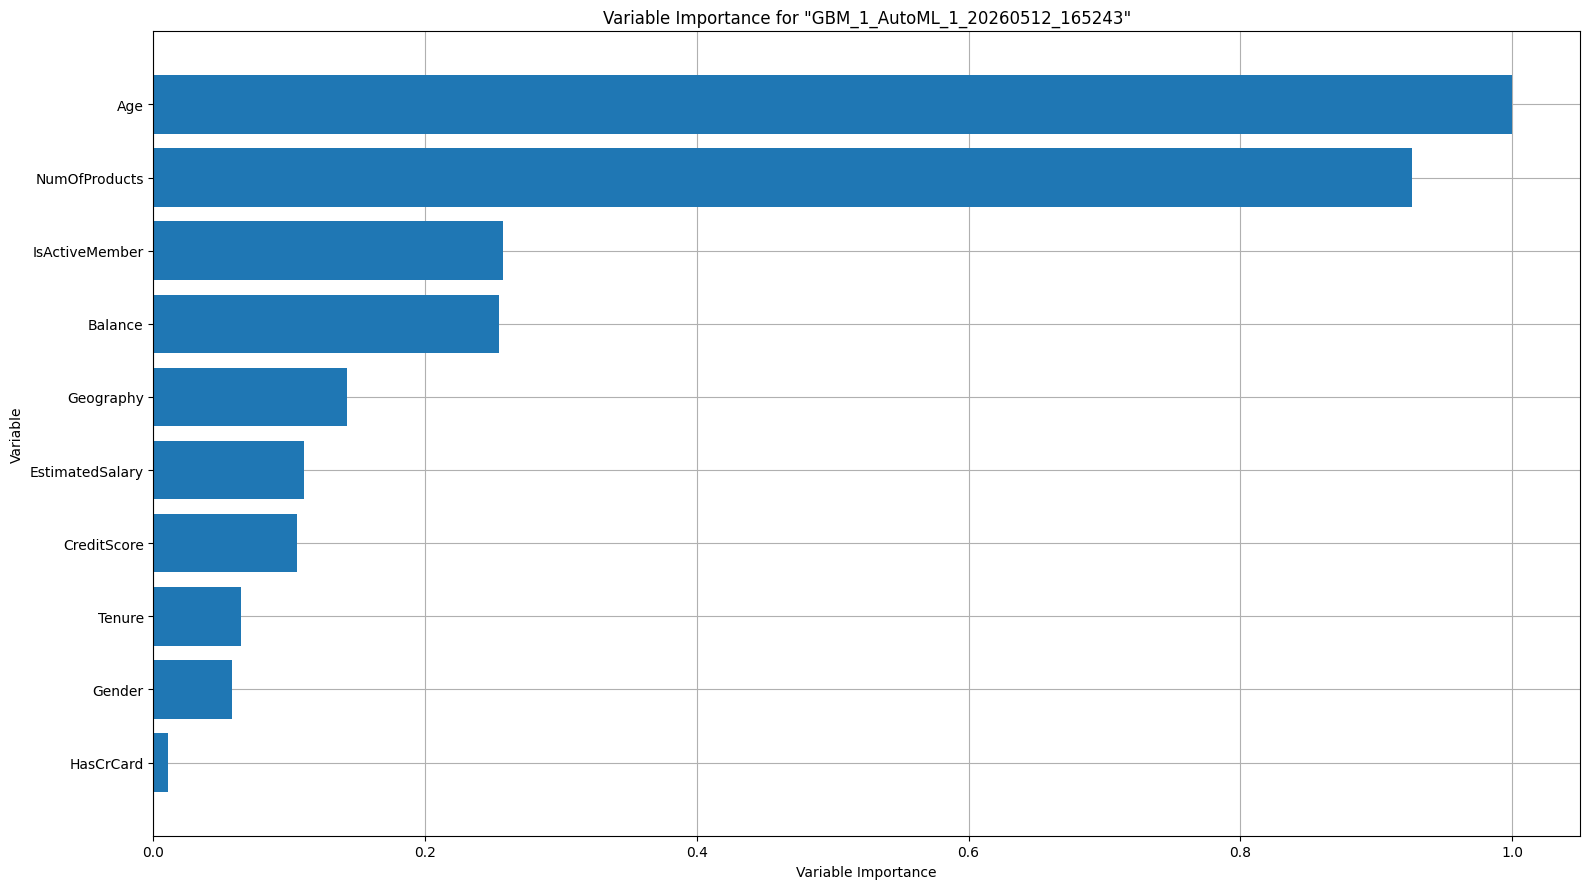

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

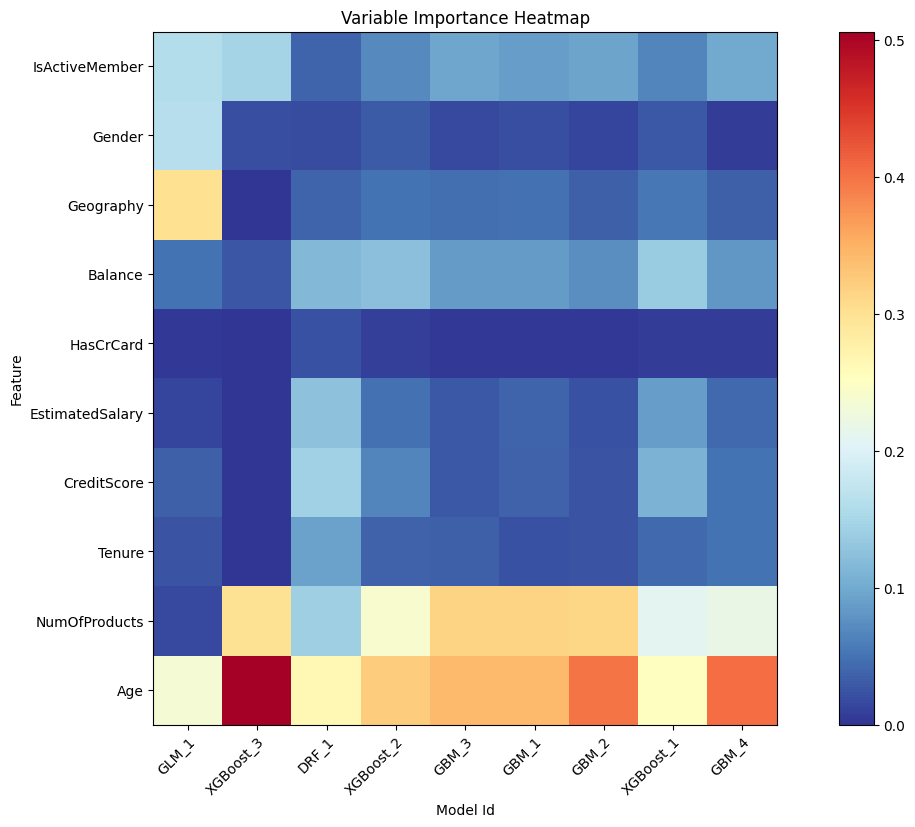

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

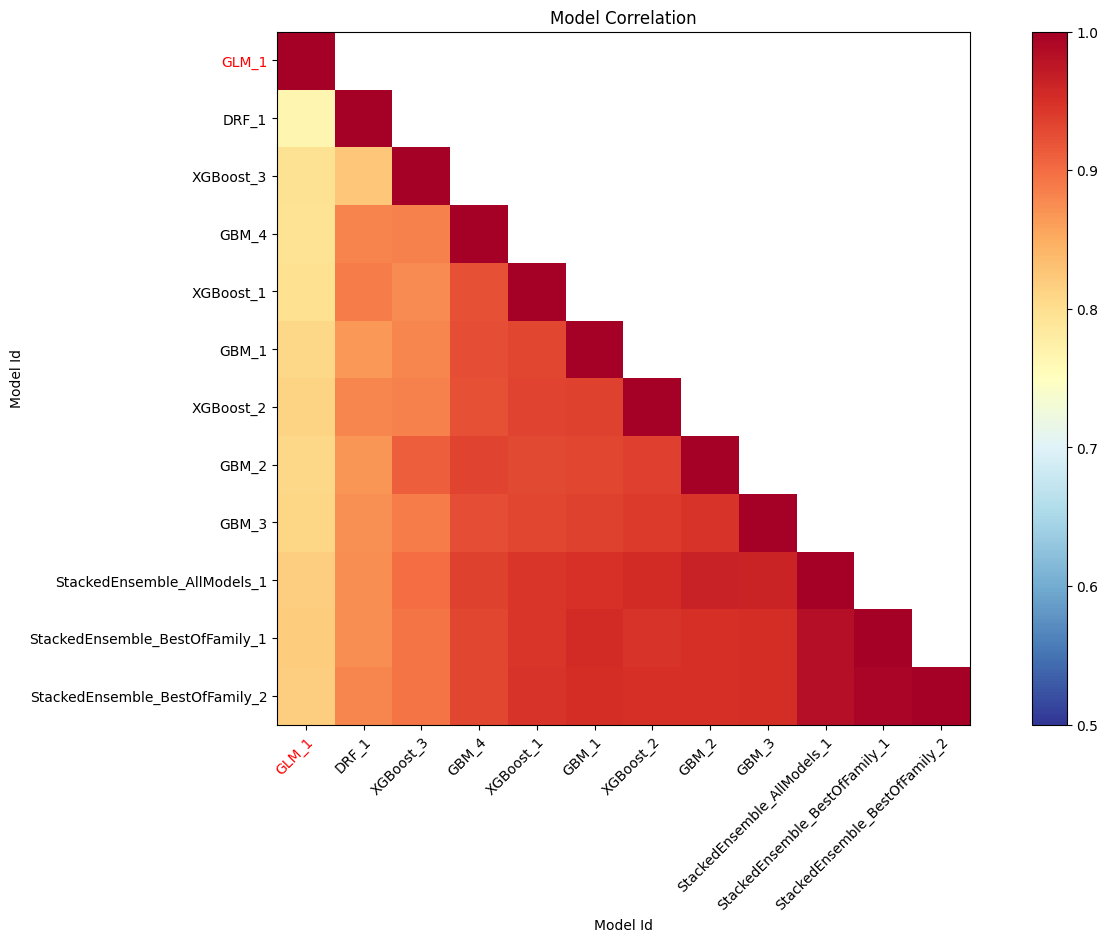

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

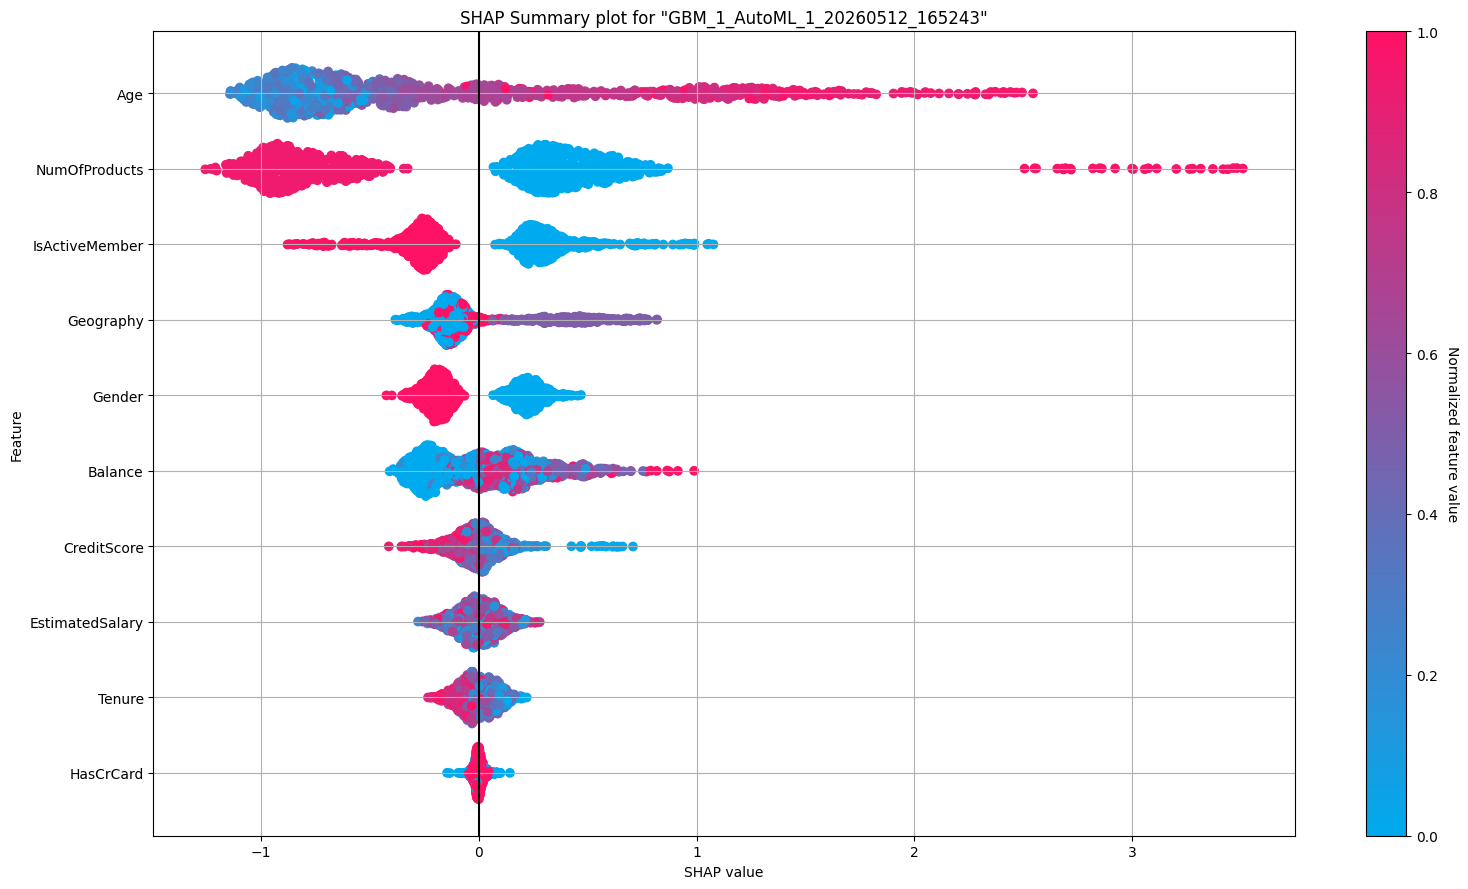

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

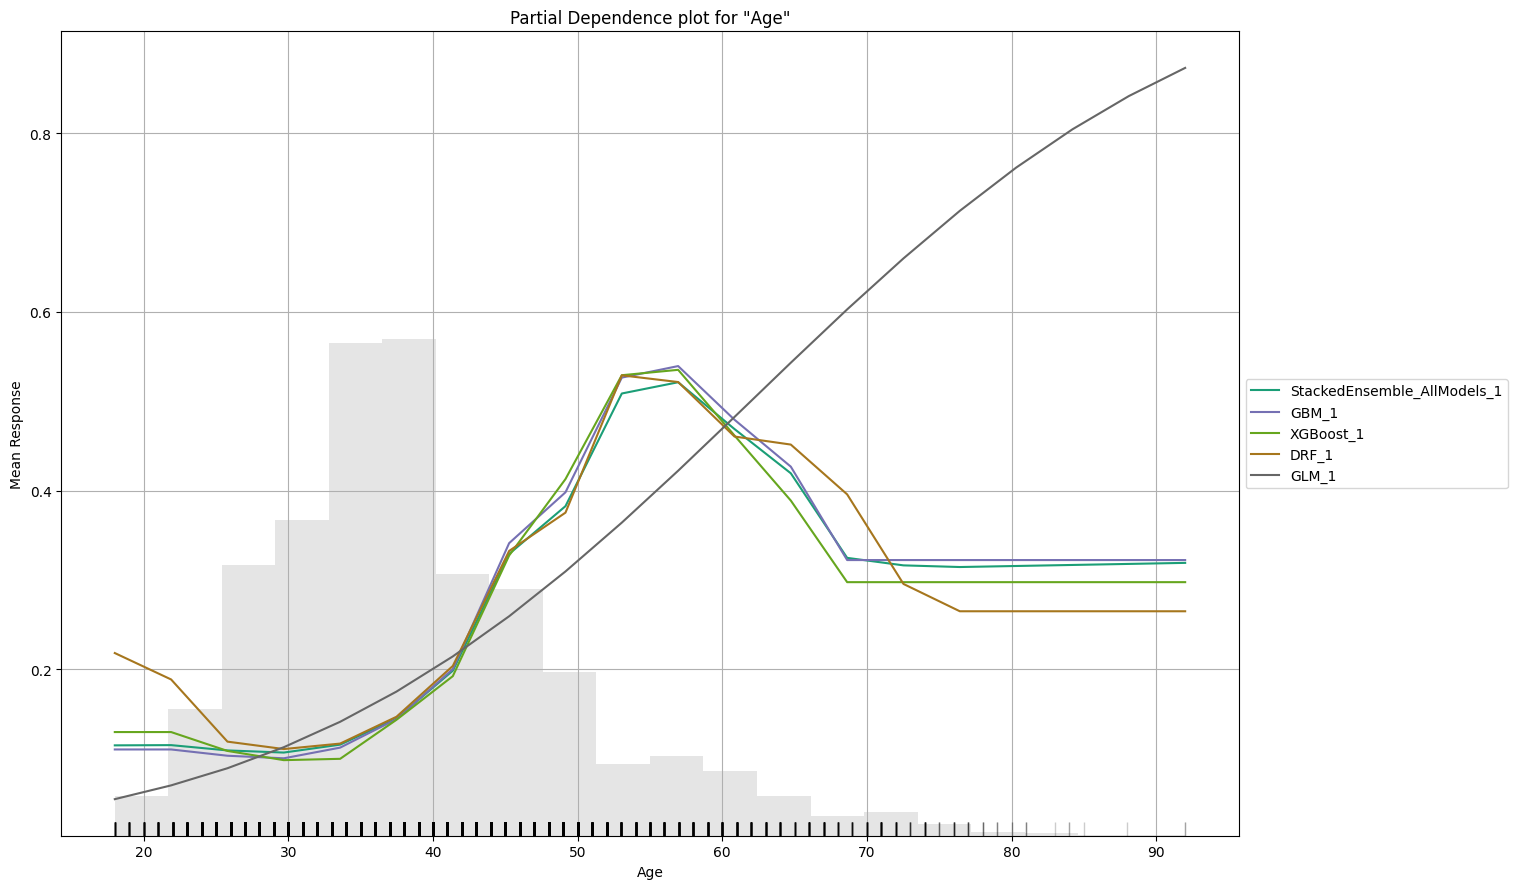

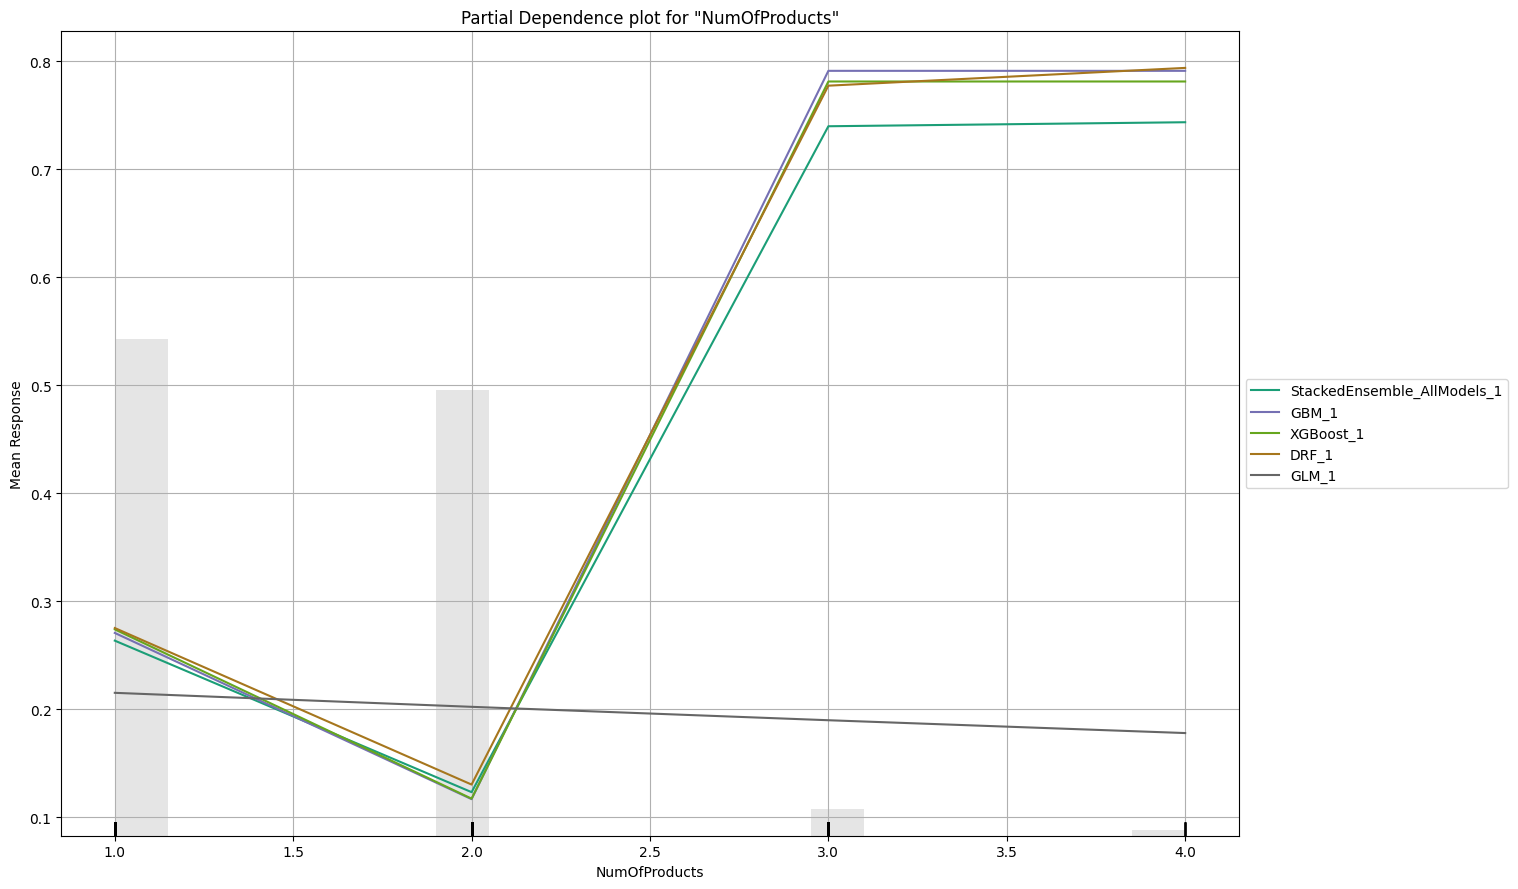

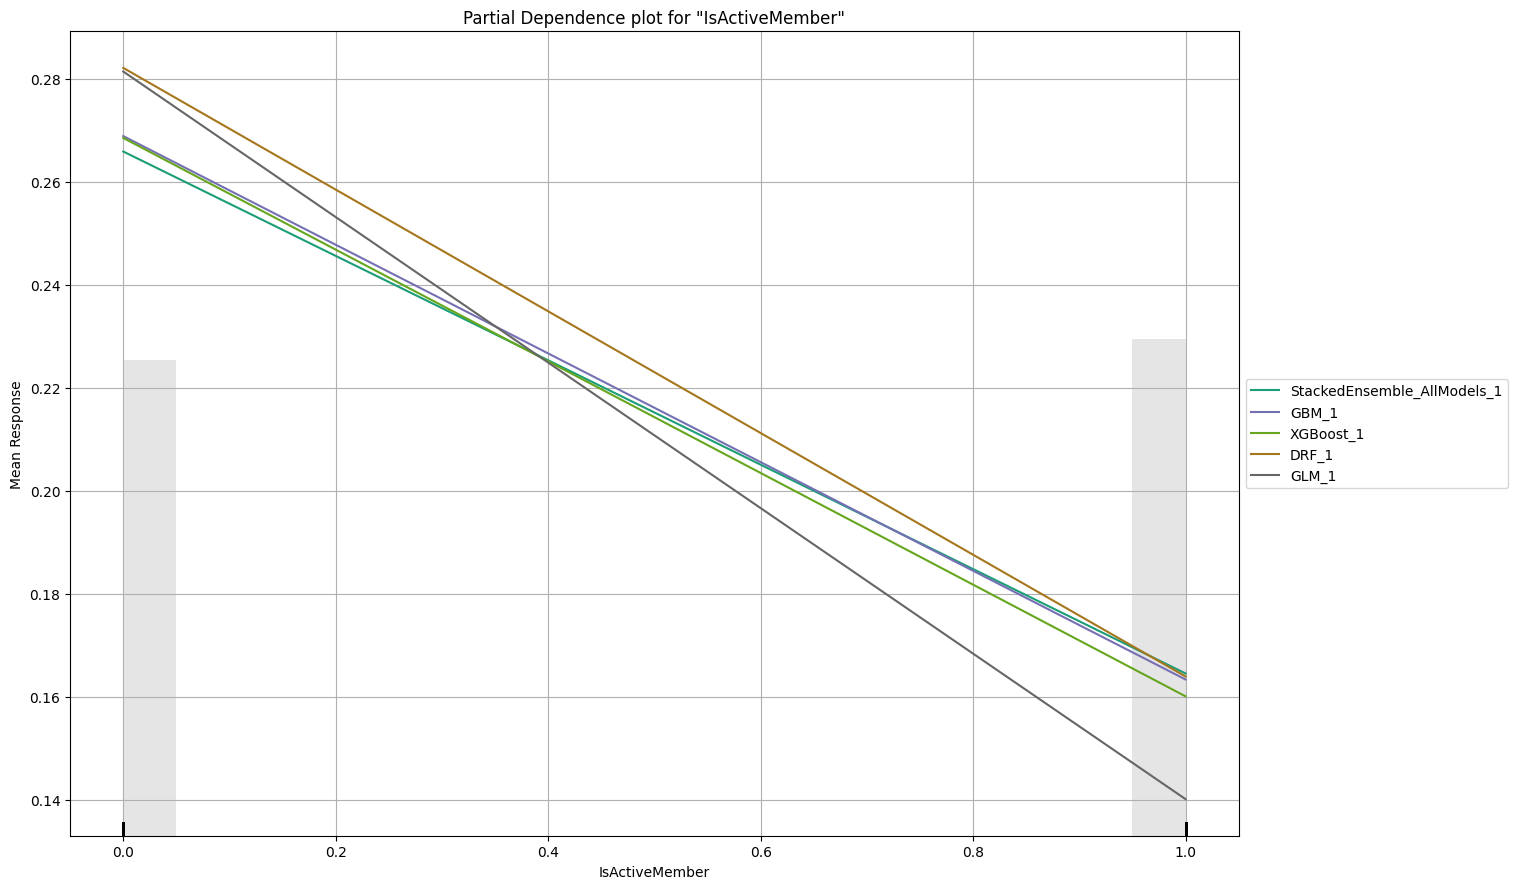

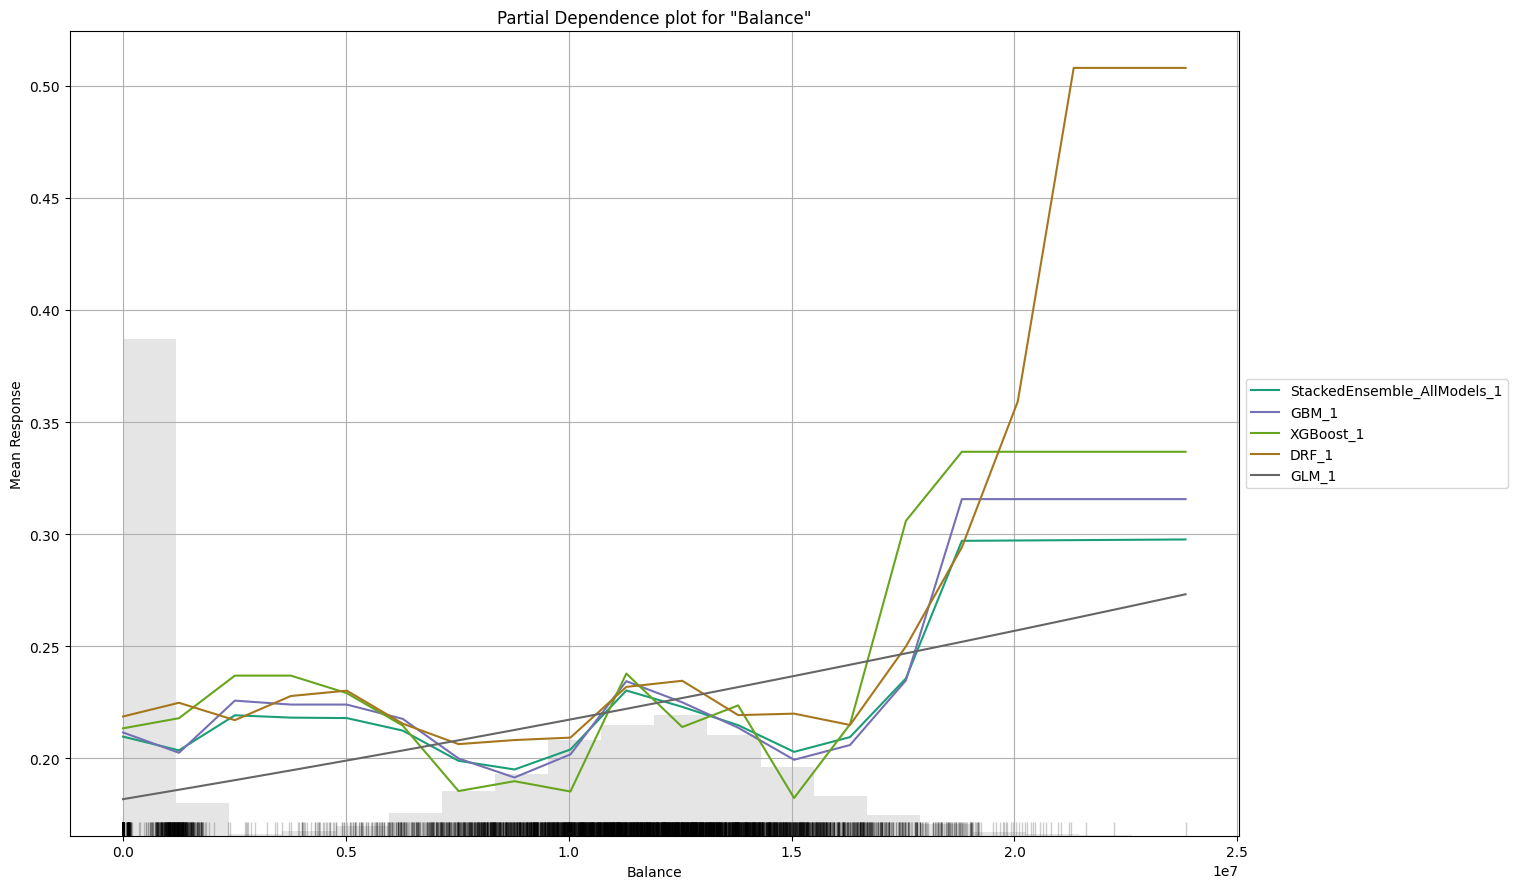

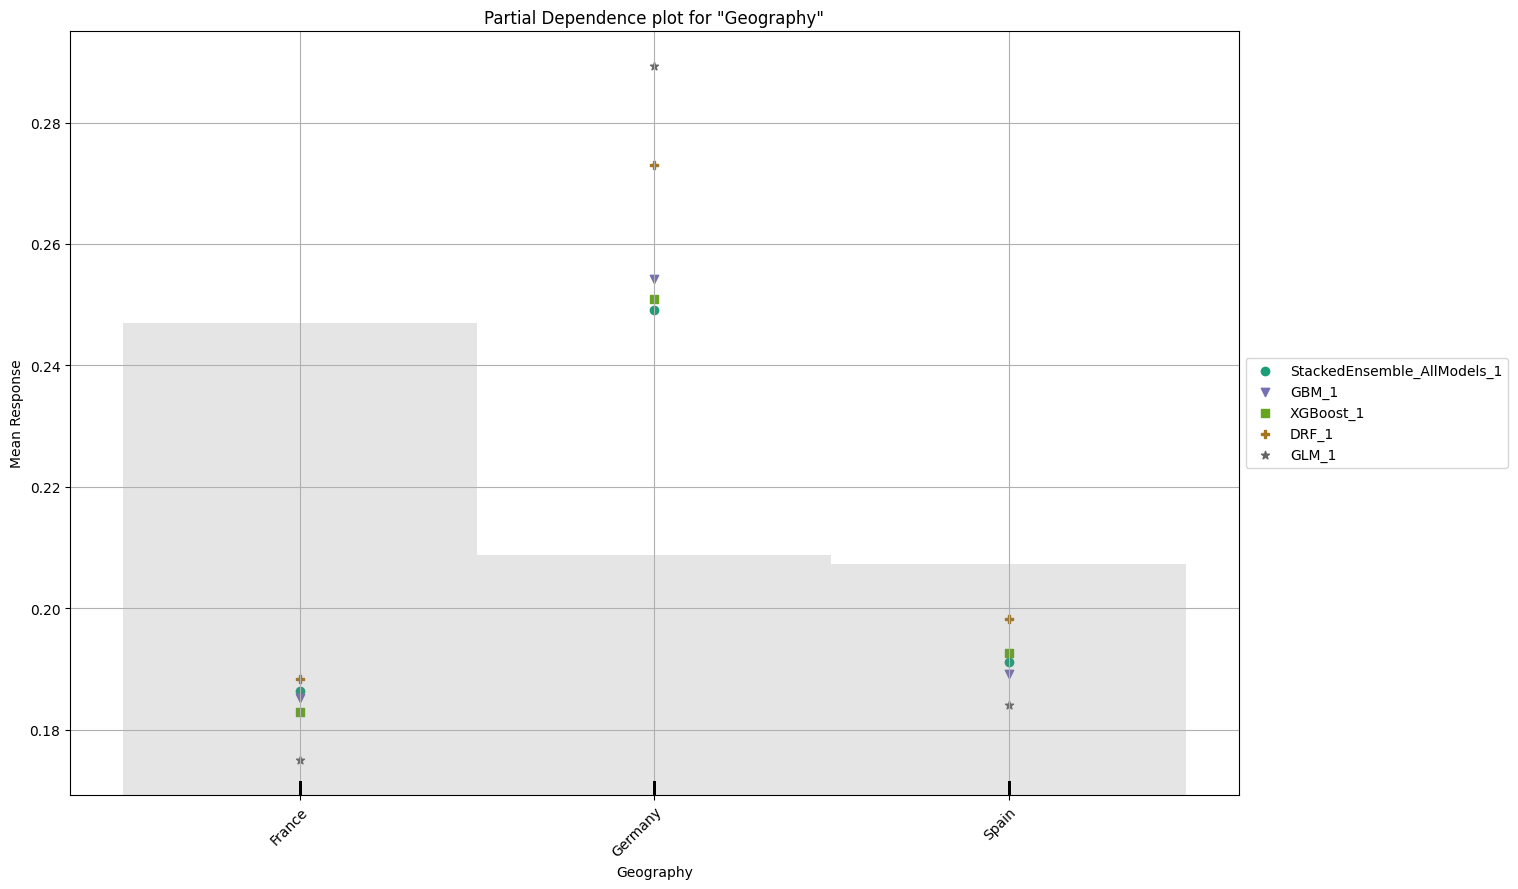

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
DRF_1_AutoML_1_20260512_165243,0.990502,0.143158,0.97461,0.0375918,0.176868,0.0312823,283,0.004141,DRF
GBM_4_AutoML_1_20260512_165243,0.940084,0.375755,0.837167,0.149546,0.336955,0.113539,282,0.016894,GBM
XGBoost_1_AutoML_1_20260512_165243,0.929555,0.263903,0.826859,0.158703,0.280001,0.0784005,1318,0.01419,XGBoost
StackedEnsemble_BestOfFamily_2_AutoML_1_20260512_165243,0.923653,0.281687,0.796436,0.16071,0.291819,0.0851584,1607,0.037151,StackedEnsemble
StackedEnsemble_AllModels_1_AutoML_1_20260512_165243,0.921022,0.294318,0.796334,0.171824,0.296267,0.0877743,1546,0.044877,StackedEnsemble
StackedEnsemble_BestOfFamily_1_AutoML_1_20260512_165243,0.919586,0.285604,0.788241,0.163901,0.294228,0.0865699,1635,0.045671,StackedEnsemble
GBM_1_AutoML_1_20260512_165243,0.918609,0.289502,0.784327,0.165314,0.296161,0.0877113,2360,0.029576,GBM
XGBoost_2_AutoML_1_20260512_165243,0.917947,0.29782,0.802287,0.174624,0.293857,0.0863521,345,0.00829,XGBoost
GBM_3_AutoML_1_20260512_165243,0.916855,0.379367,0.796425,0.184752,0.338708,0.114723,320,0.011735,GBM
GBM_2_AutoML_1_20260512_165243,0.900799,0.376603,0.771181,0.198517,0.337203,0.113706,307,0.021426,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_AllModels_1_AutoML_1_20260512_165243

,0,1,Error,Rate
0,4988.0,529.0,0.0959,(529.0/5517.0)
1,360.0,1093.0,0.2478,(360.0/1453.0)
Total,5348.0,1622.0,0.1275,(889.0/6970.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

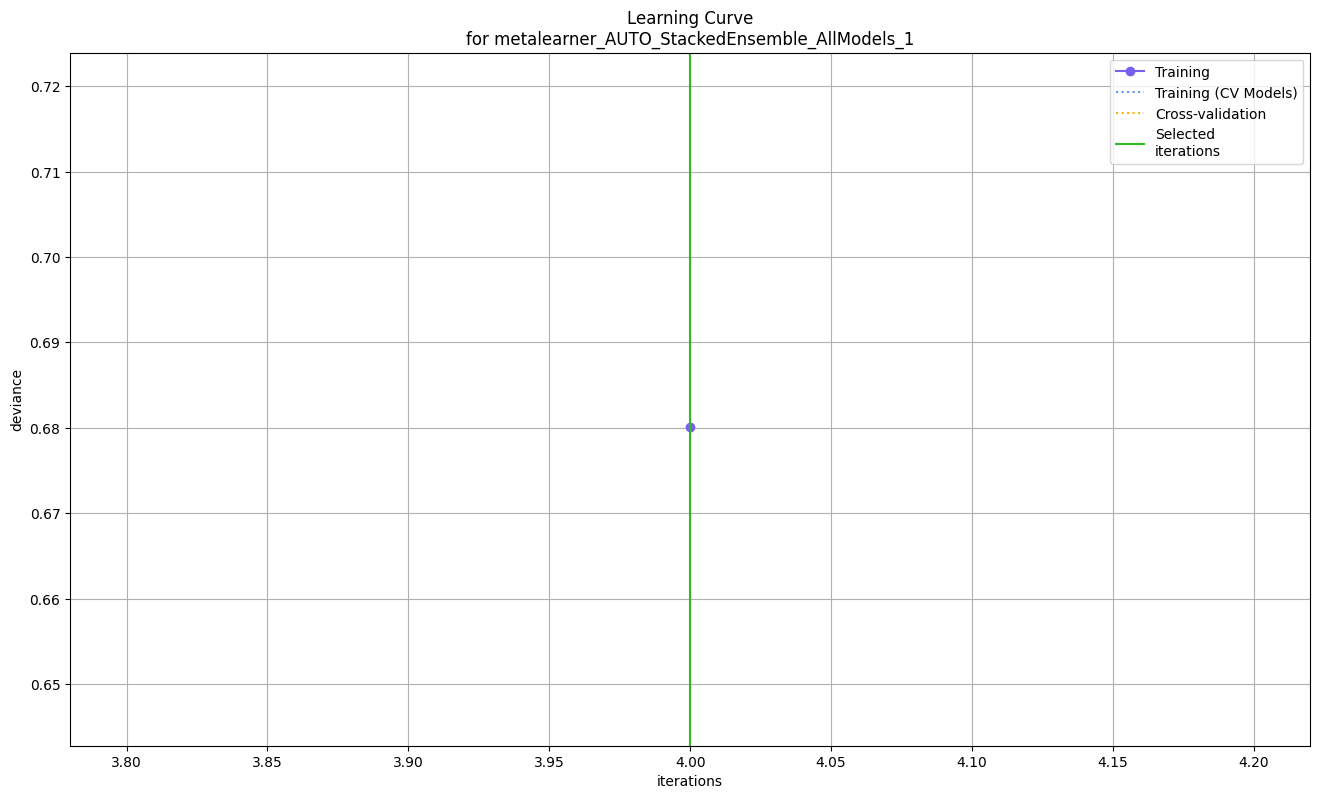

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

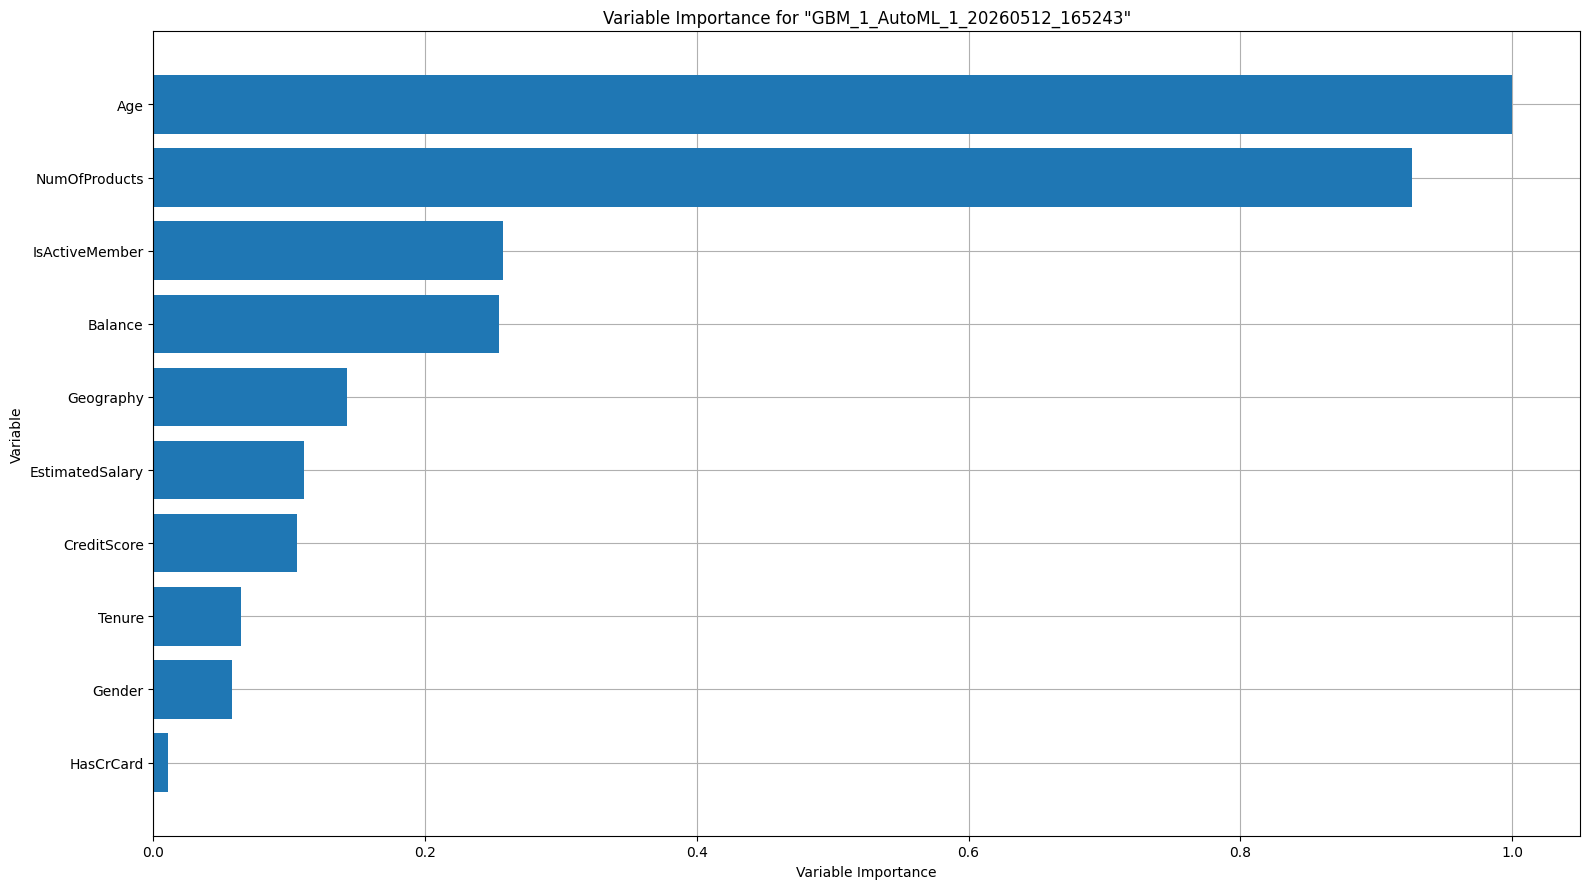

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

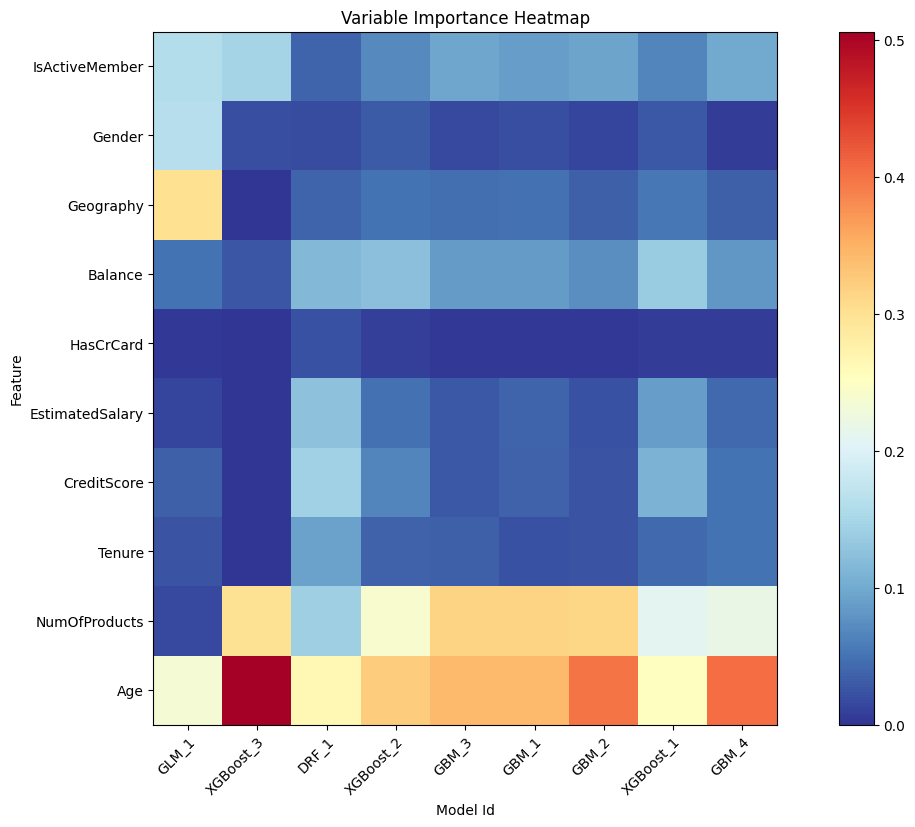

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

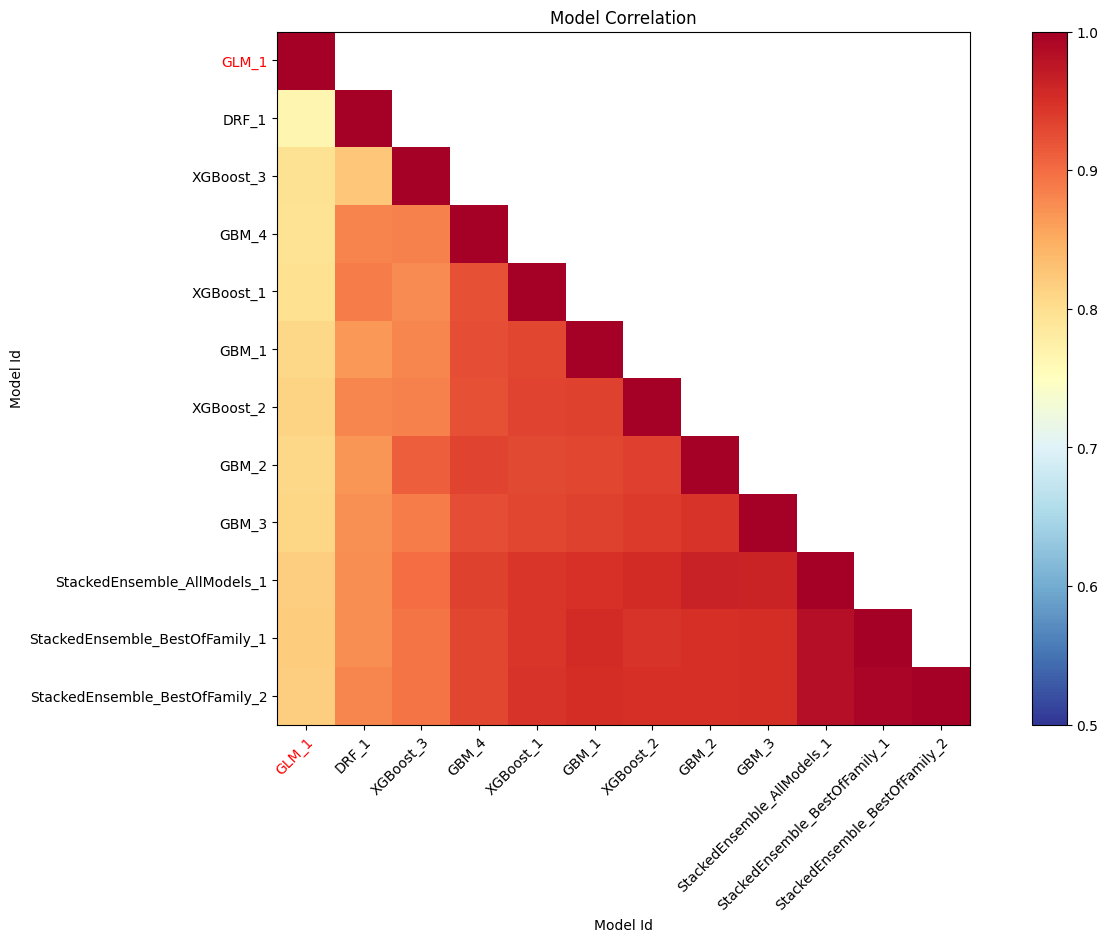

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

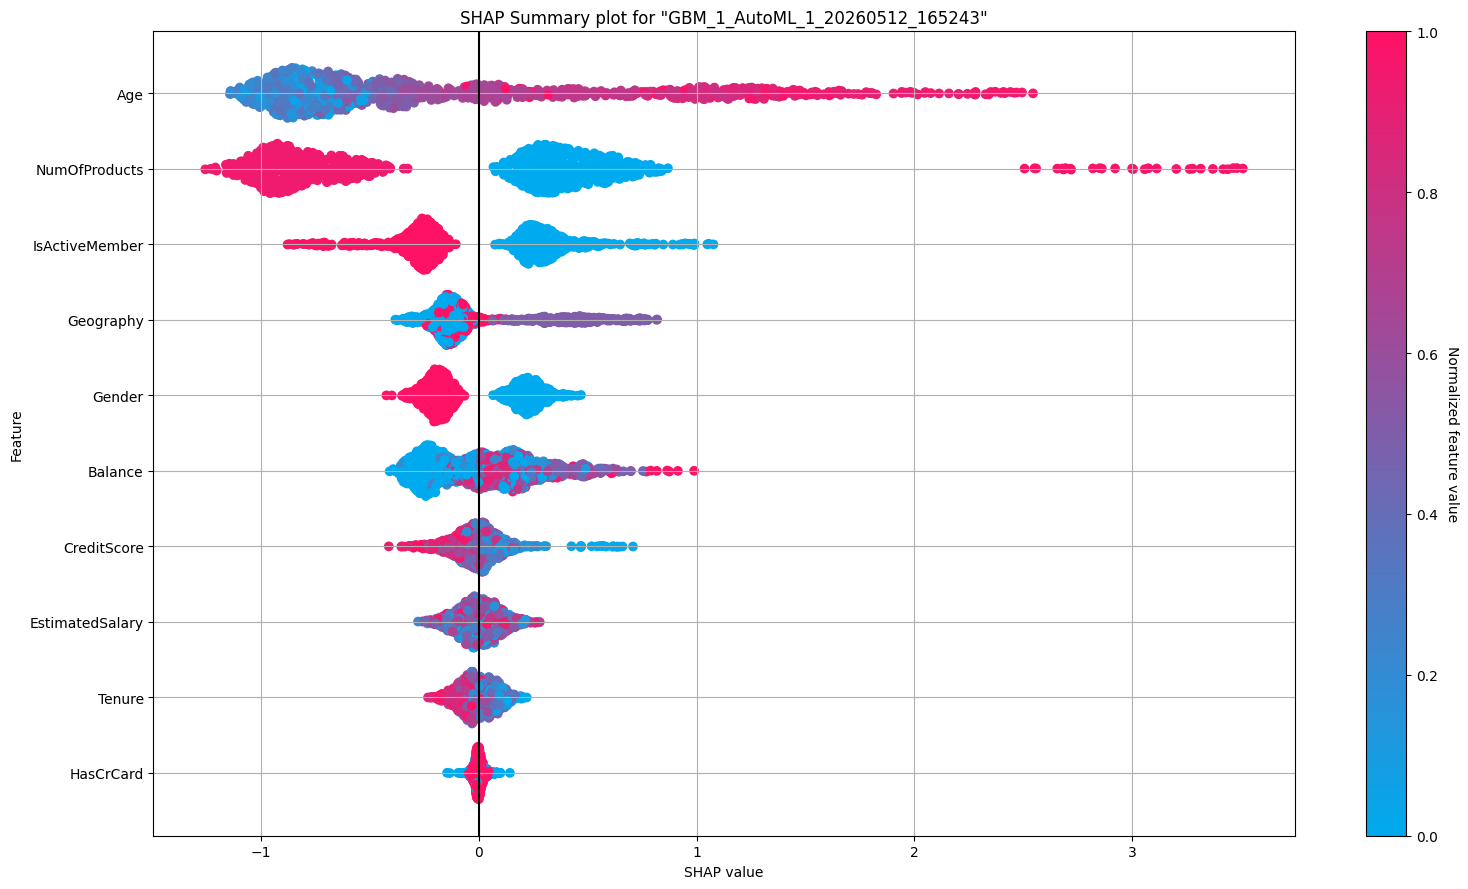

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

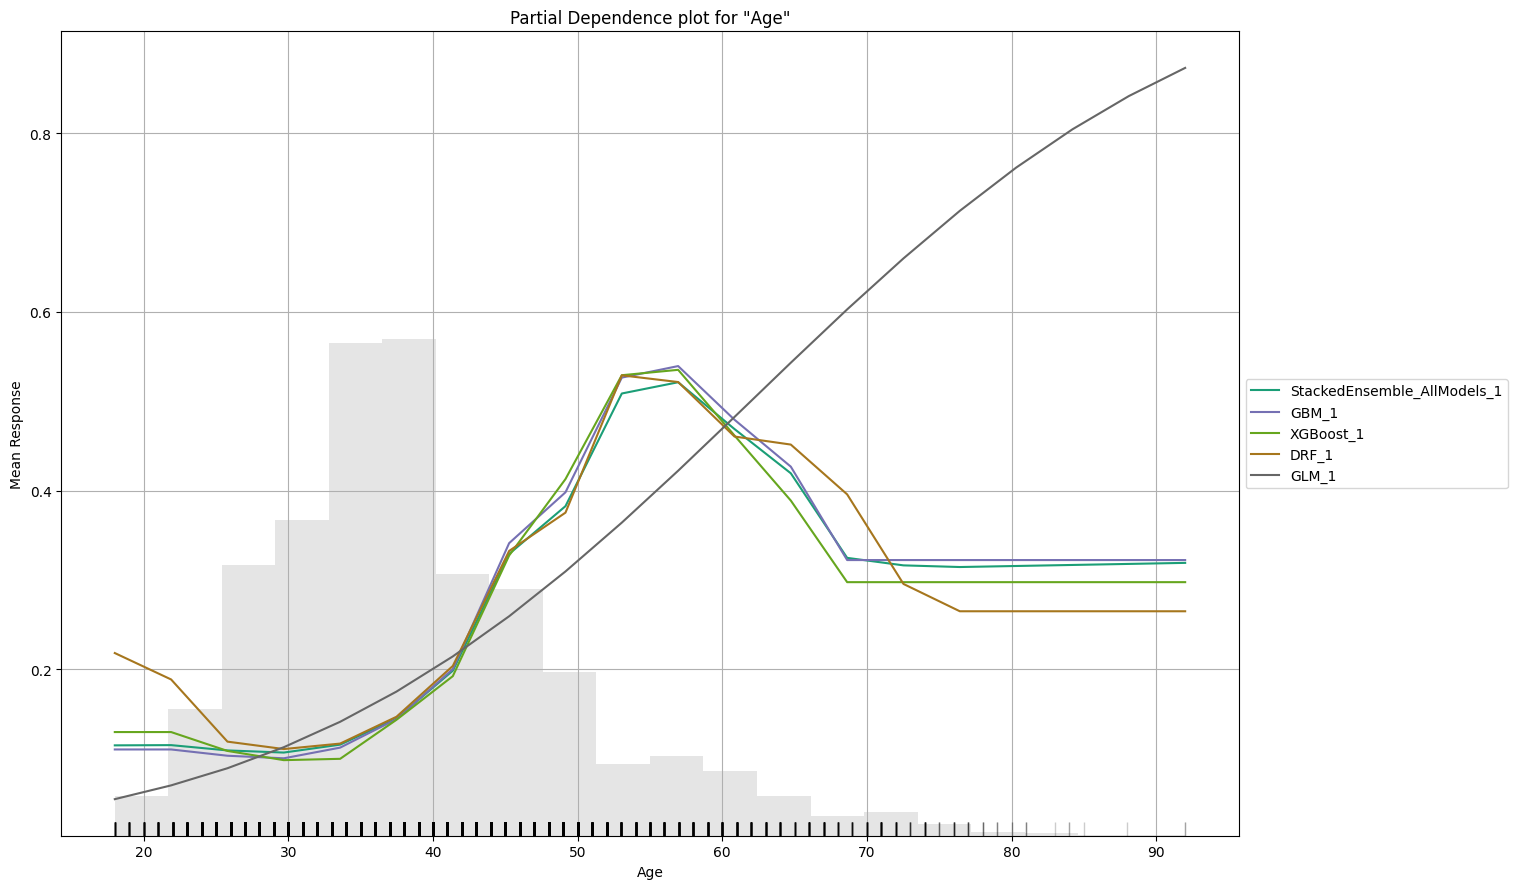

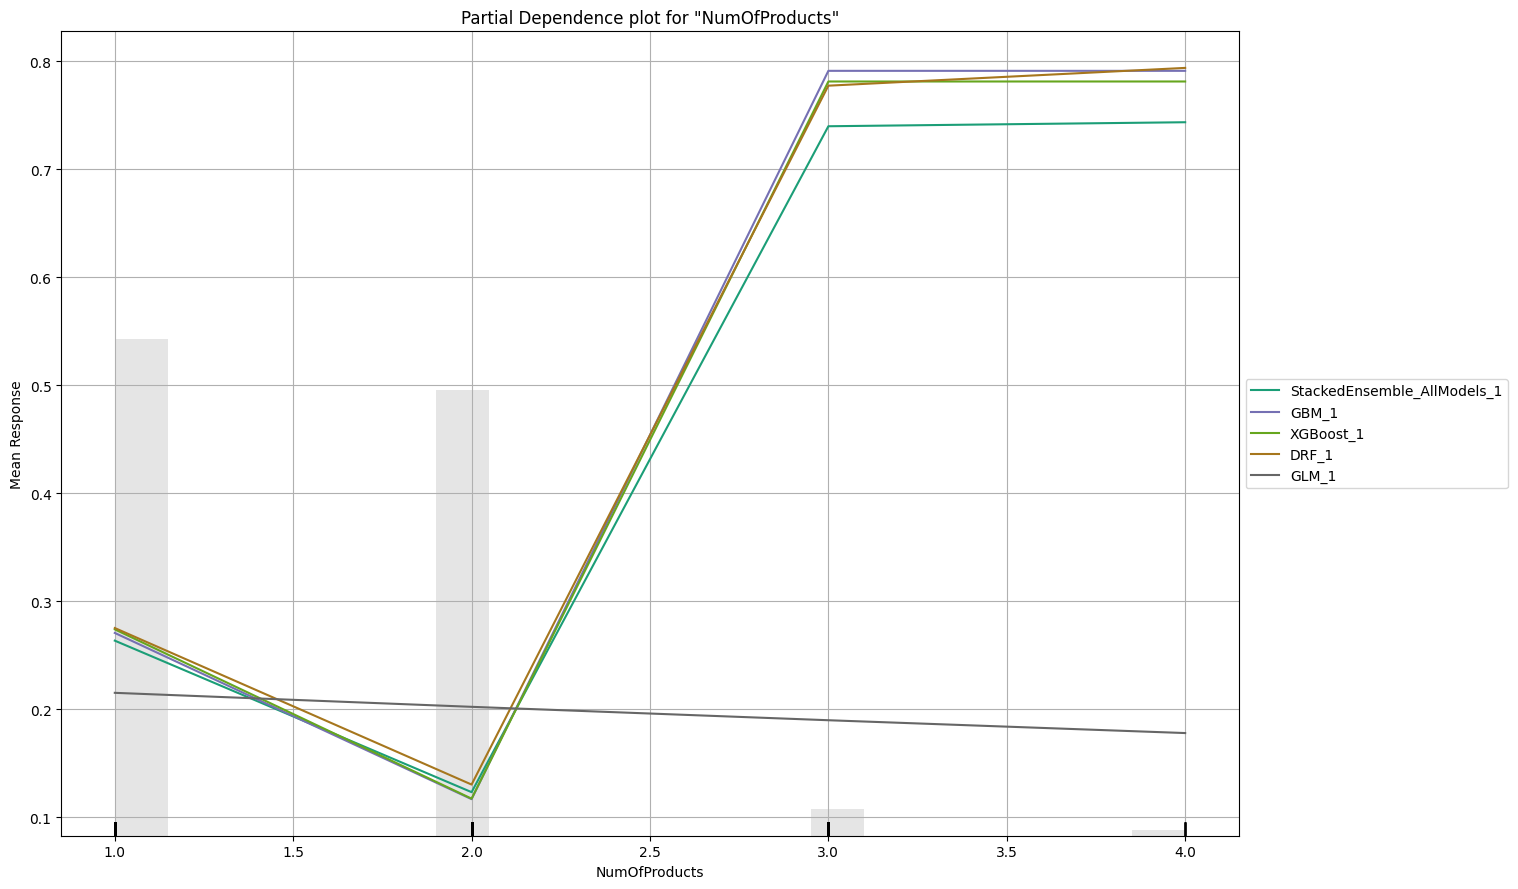

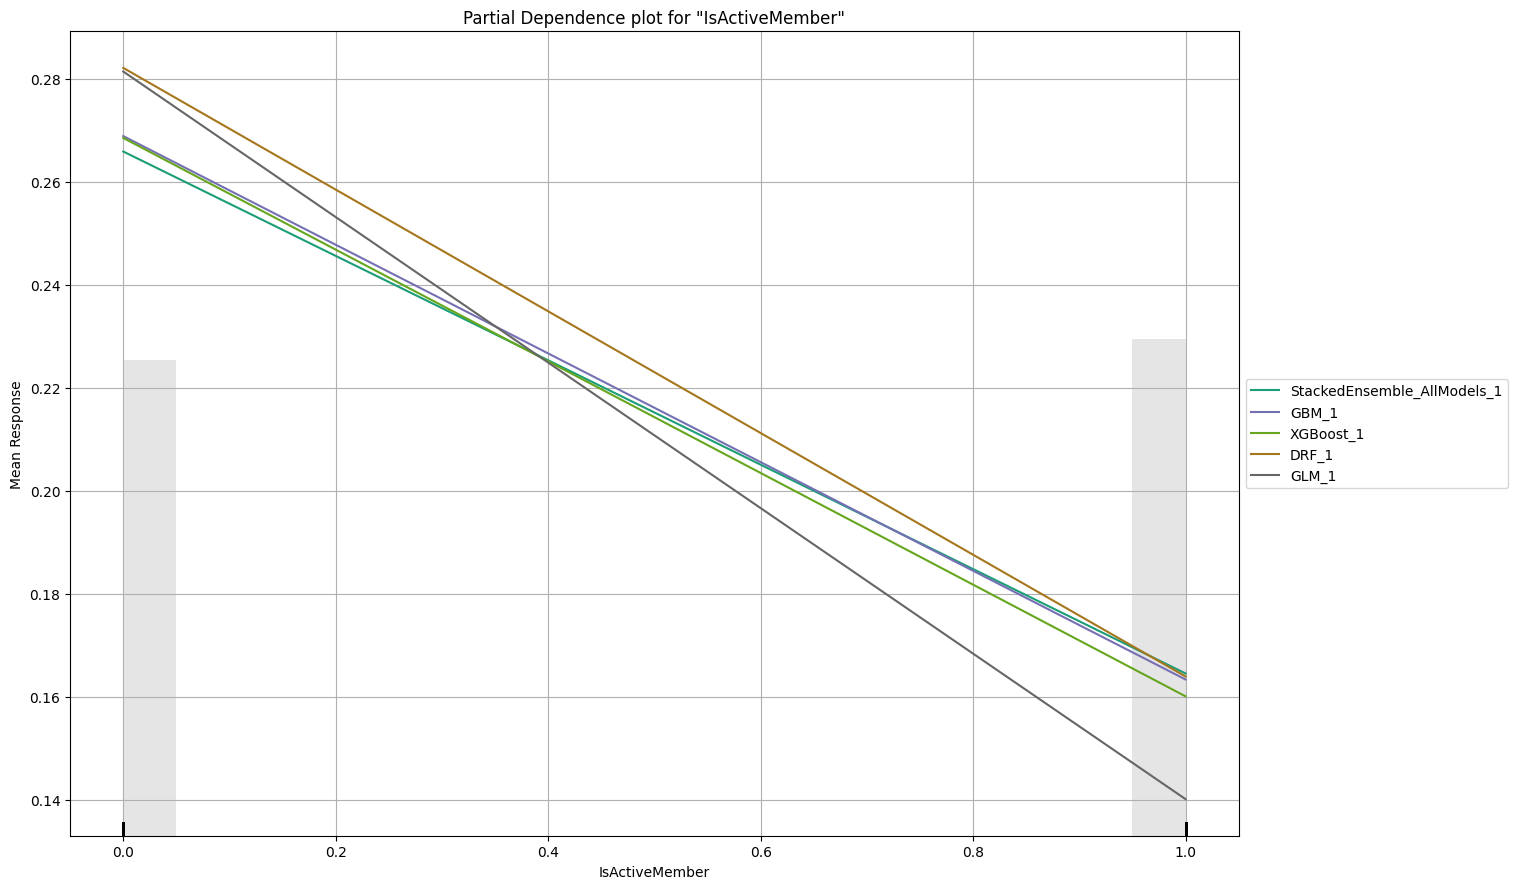

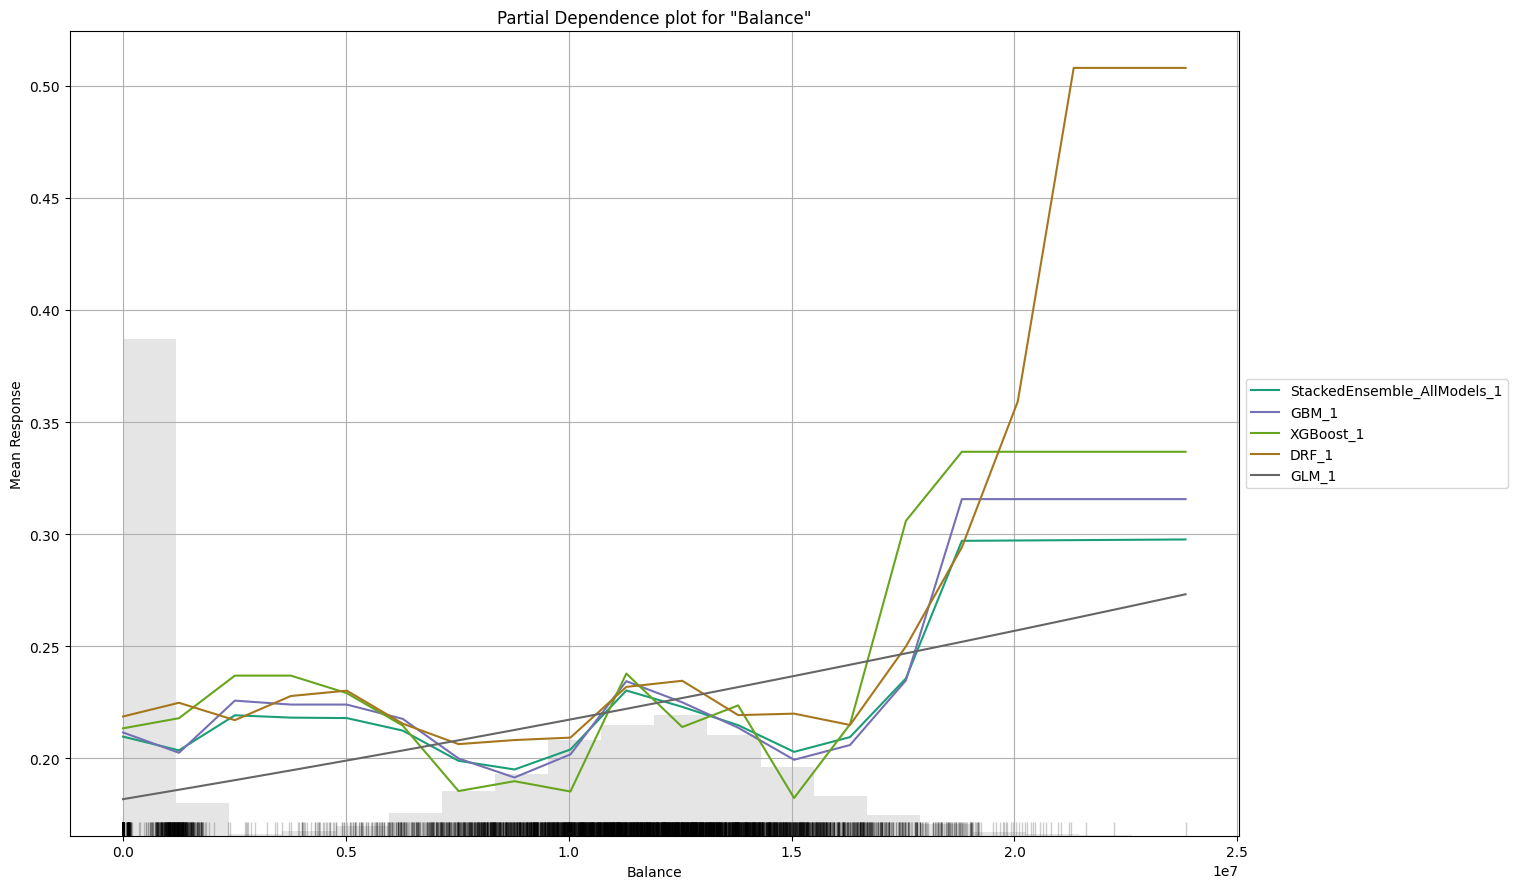

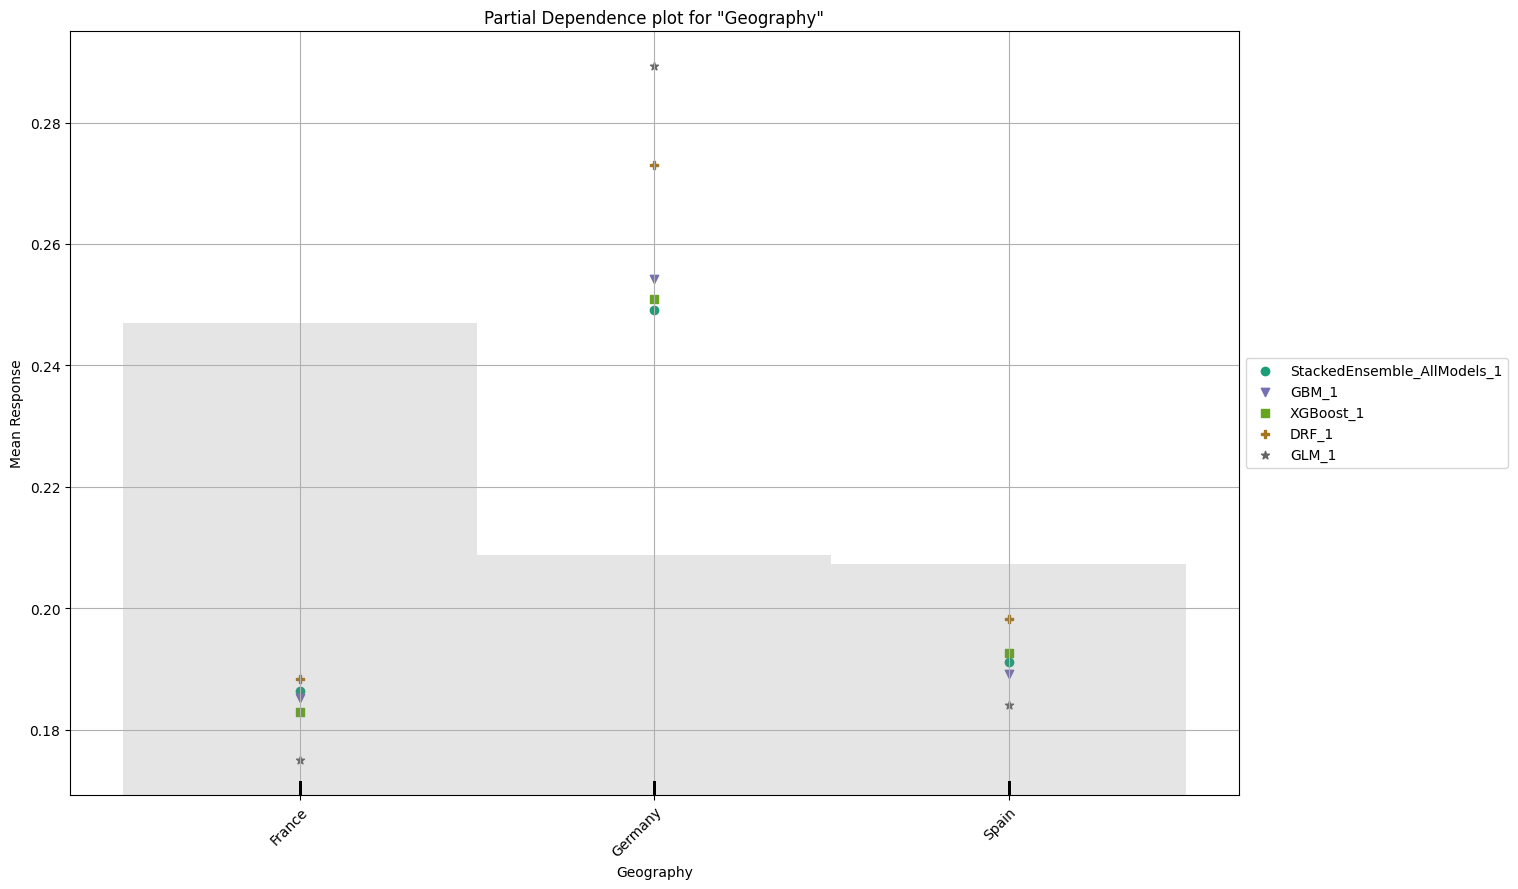

In [7]:
modelo.explain(treino)

# Leaderboard

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
StackedEnsemble_AllModels_1_AutoML_1_20260512_165243,0.851576,0.33971,0.672445,0.245263,0.320451,0.102689,1546,0.042952,StackedEnsemble,0,0.937328,0.0626718
StackedEnsemble_BestOfFamily_1_AutoML_1_20260512_165243,0.849084,0.340997,0.665567,0.253979,0.321973,0.103667,1635,0.030842,StackedEnsemble,0,0.951689,0.0483114
StackedEnsemble_BestOfFamily_2_AutoML_1_20260512_165243,0.848889,0.341051,0.665537,0.253775,0.321971,0.103665,1607,0.036137,StackedEnsemble,0,0.951358,0.0486416
GBM_1_AutoML_1_20260512_165243,0.84841,0.341558,0.66422,0.244955,0.322198,0.103811,2360,0.029288,GBM,0,0.947453,0.0525471
GBM_2_AutoML_1_20260512_165243,0.848015,0.38474,0.668252,0.244292,0.340789,0.116137,307,0.014638,GBM,0,0.86933,0.13067
GBM_3_AutoML_1_20260512_165243,0.844909,0.39348,0.65889,0.258796,0.345468,0.119348,320,0.011327,GBM,0,0.870114,0.129886
XGBoost_2_AutoML_1_20260512_165243,0.841191,0.350663,0.652888,0.239893,0.324969,0.105605,345,0.013436,XGBoost,0,0.927446,0.0725545
XGBoost_1_AutoML_1_20260512_165243,0.839208,0.354129,0.641468,0.260763,0.328096,0.107647,1318,0.012844,XGBoost,0,0.967316,0.0326837
GBM_4_AutoML_1_20260512_165243,0.829757,0.401051,0.639842,0.247699,0.349456,0.122119,282,0.00995,GBM,0,0.848157,0.151843
XGBoost_3_AutoML_1_20260512_165243,0.817078,0.554159,0.588362,0.275736,0.426402,0.181818,75,0.002766,XGBoost,0,0.626655,0.373345


# SHAP Explanation

> SHAP explanation shows contribution of features for a given instance. The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function. H2O implements TreeSHAP which when the features are correlated, can increase contribution of a feature that had no influence on the prediction.

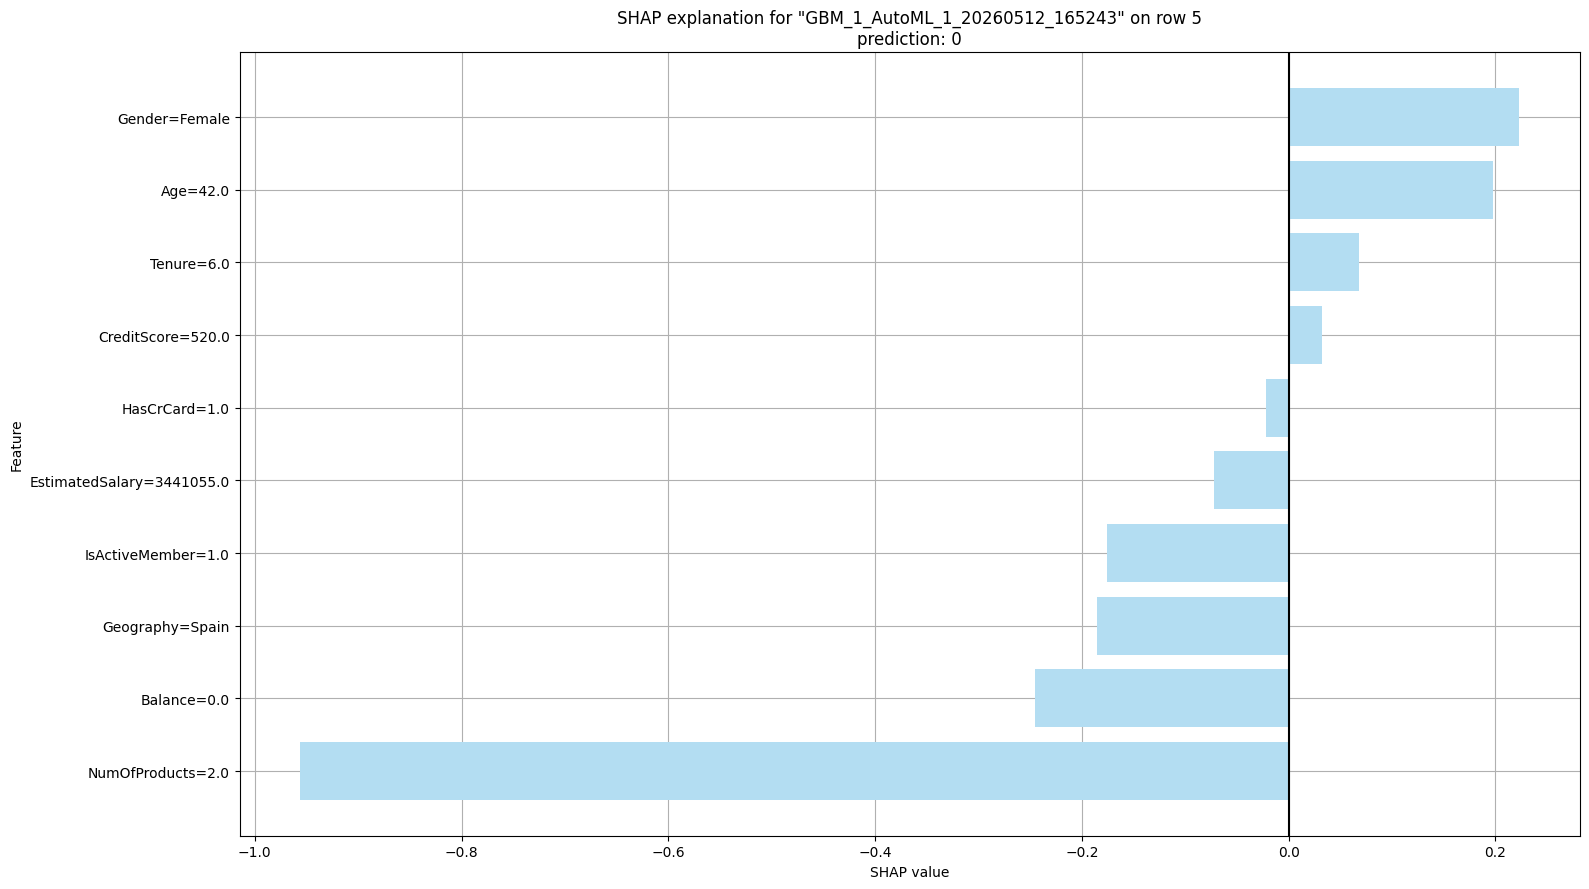

# Leaderboard

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
StackedEnsemble_AllModels_1_AutoML_1_20260512_165243,0.851576,0.33971,0.672445,0.245263,0.320451,0.102689,1546,0.042952,StackedEnsemble,0,0.937328,0.0626718
StackedEnsemble_BestOfFamily_1_AutoML_1_20260512_165243,0.849084,0.340997,0.665567,0.253979,0.321973,0.103667,1635,0.030842,StackedEnsemble,0,0.951689,0.0483114
StackedEnsemble_BestOfFamily_2_AutoML_1_20260512_165243,0.848889,0.341051,0.665537,0.253775,0.321971,0.103665,1607,0.036137,StackedEnsemble,0,0.951358,0.0486416
GBM_1_AutoML_1_20260512_165243,0.84841,0.341558,0.66422,0.244955,0.322198,0.103811,2360,0.029288,GBM,0,0.947453,0.0525471
GBM_2_AutoML_1_20260512_165243,0.848015,0.38474,0.668252,0.244292,0.340789,0.116137,307,0.014638,GBM,0,0.86933,0.13067
GBM_3_AutoML_1_20260512_165243,0.844909,0.39348,0.65889,0.258796,0.345468,0.119348,320,0.011327,GBM,0,0.870114,0.129886
XGBoost_2_AutoML_1_20260512_165243,0.841191,0.350663,0.652888,0.239893,0.324969,0.105605,345,0.013436,XGBoost,0,0.927446,0.0725545
XGBoost_1_AutoML_1_20260512_165243,0.839208,0.354129,0.641468,0.260763,0.328096,0.107647,1318,0.012844,XGBoost,0,0.967316,0.0326837
GBM_4_AutoML_1_20260512_165243,0.829757,0.401051,0.639842,0.247699,0.349456,0.122119,282,0.00995,GBM,0,0.848157,0.151843
XGBoost_3_AutoML_1_20260512_165243,0.817078,0.554159,0.588362,0.275736,0.426402,0.181818,75,0.002766,XGBoost,0,0.626655,0.373345


# SHAP Explanation

> SHAP explanation shows contribution of features for a given instance. The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function. H2O implements TreeSHAP which when the features are correlated, can increase contribution of a feature that had no influence on the prediction.

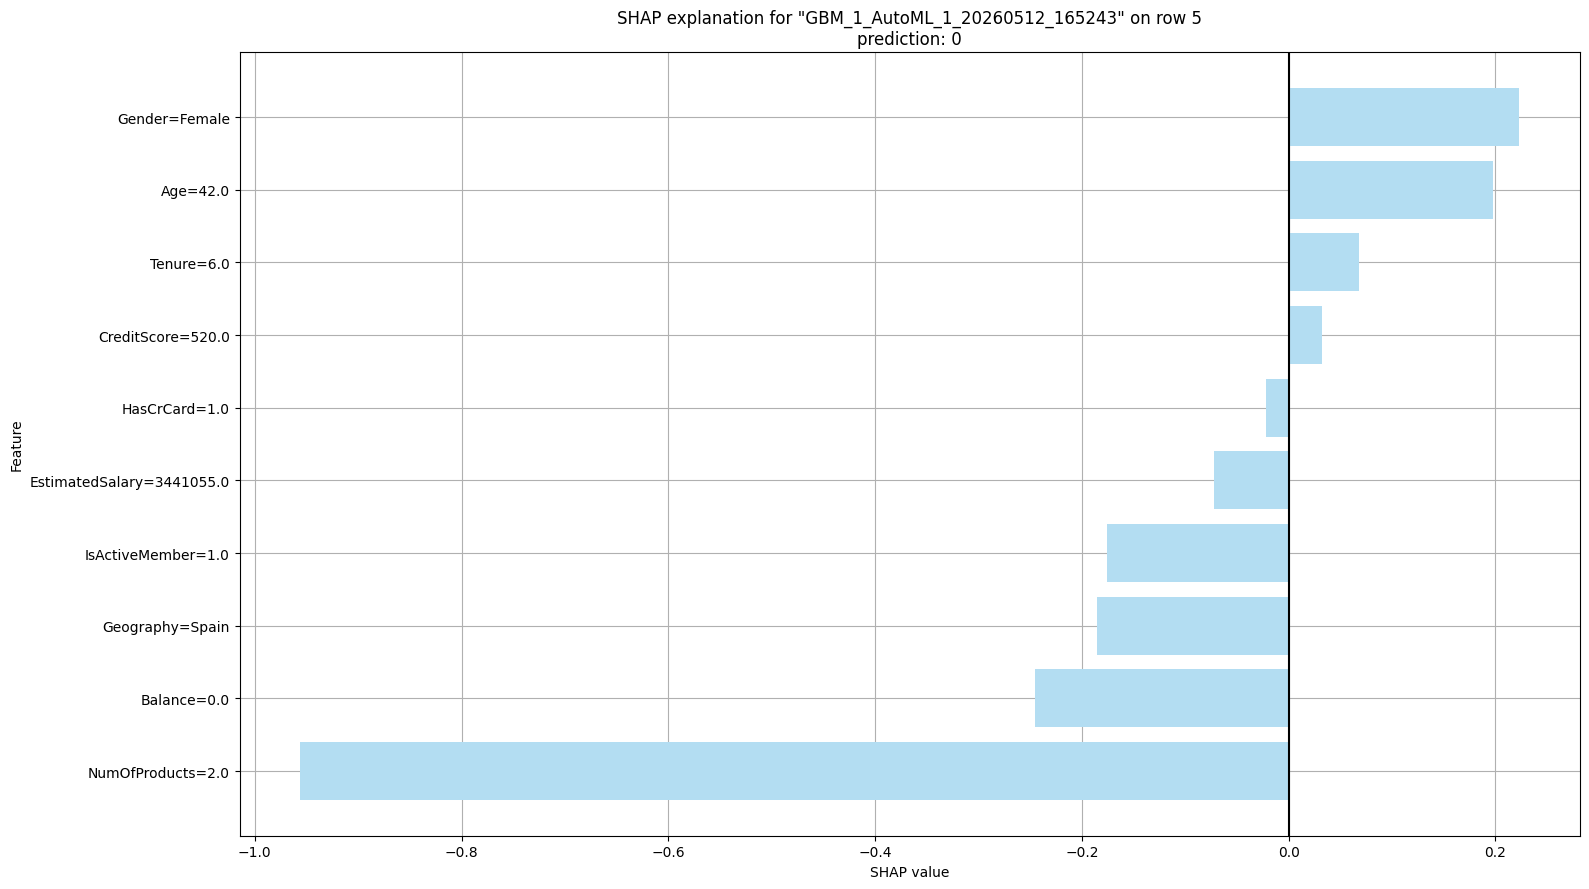

In [8]:
modelo.explain_row(teste, row_index=5)

In [7]:
ranking = modelo.leaderboard
ranking = ranking.as_data_frame(use_multi_thread=True)
ranking

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,StackedEnsemble_AllModels_2_AutoML_1_20260510_...,0.858844,0.340825,0.696948,0.229631,0.321958,0.103657
1,StackedEnsemble_AllModels_3_AutoML_1_20260510_...,0.858424,0.340787,0.698441,0.234474,0.321611,0.103434
2,StackedEnsemble_BestOfFamily_3_AutoML_1_202605...,0.858079,0.340985,0.696940,0.231784,0.321875,0.103603
3,GBM_5_AutoML_1_20260510_182836,0.856552,0.343510,0.692164,0.239359,0.322763,0.104176
4,StackedEnsemble_AllModels_1_AutoML_1_20260510_...,0.856196,0.343942,0.692022,0.239554,0.323593,0.104713
5,GBM_grid_1_AutoML_1_20260510_182836_model_5,0.856109,0.347084,0.687426,0.236772,0.325021,0.105639
6,StackedEnsemble_BestOfFamily_2_AutoML_1_202605...,0.855482,0.345406,0.690049,0.229714,0.324353,0.105205
7,StackedEnsemble_BestOfFamily_1_AutoML_1_202605...,0.855247,0.345677,0.689281,0.231406,0.324439,0.105261
8,GBM_grid_1_AutoML_1_20260510_182836_model_6,0.855183,0.347690,0.689832,0.241343,0.325102,0.105691
9,GBM_1_AutoML_1_20260510_182836,0.854820,0.346471,0.689439,0.243777,0.324772,0.105477


In [8]:
df_test = pd.read_csv("../data/Churn_teste.csv", sep=";")
df_test = h2o.H2OFrame(teste)

In [9]:
prever = modelo.leader.predict(df_test)
prever = prever.as_data_frame(use_multi_thread=True)
prever

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,predict,p0,p1
0,0,0.941189,0.058811
1,0,0.892592,0.107408
2,0,0.989695,0.010305
3,0,0.981925,0.018075
4,0,0.977666,0.022334
...,...,...,...
2989,0,0.724747,0.275253
2990,0,0.963648,0.036352
2991,0,0.856080,0.143920
2992,0,0.736438,0.263562
